# Exercise 1: Linear regression
Initially we will work on 2D points and then expand it out to 3D.

We'll do the necessary imports for the notebook and then generate some data.

The data generation is as follows:
$$
x \sim \mathcal{N}(\mu_x, \sigma_x^2)
$$ 
with $\mu_x=1.5$ being the mean and $\sigma_x = 2.5$ being the standard deviation.

We also add a normally distributed error term with zero mean $\mu_\epsilon=0$ and standard deviation
$\sigma_\epsilon=0.5$.

In [13]:
import numpy as np
import open3d as o3d
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# Generate 'random' data
np.random.seed(0)
x = np.random.normal(1.5, 2.5, 100)   # Array of 100 values with mean = 1.5, stddev = 2.5
res = np.random.normal(0, 0.5, 100)       # Generate 100 residual terms (mean=0, std=0.5)
y = 2 + 0.3 * x + res                  # Actual values of Y


We can use the linear regression algorithm from the `sklearn` package.
Here, we setup the model to fit `x` to `y`.

In [14]:
x_r = x.reshape(-1,1) #fit needs x in this shape
# Initialise and fit model
lm = LinearRegression()
model = lm.fit(x_r, y)

We can now predict new outcomes given new data.

In [15]:
# Draw a new datapoint
tst_x = 2.5 * np.random.randn(1).reshape(-1,1) + 1.5
print(tst_x)
resulting_y = model.predict(tst_x)
print(resulting_y)

[[0.57704541]]
[2.18951787]


Drawing 200 new samples and plotting them as a line shows us that we have gotten a decent fit.

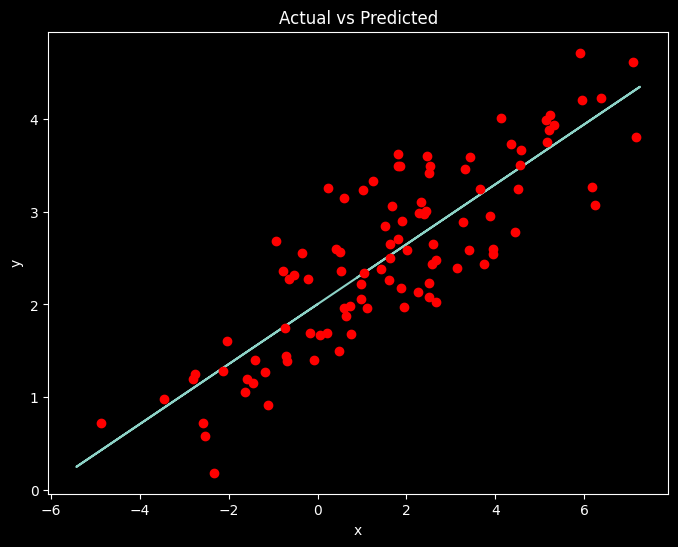

In [16]:
new_x = 2.5 * np.random.randn(200).reshape(-1,1) + 1.5
predicted = model.predict(new_x)
plt.figure(figsize=(8, 6))
plt.plot(new_x, predicted)     # regression line
plt.plot(x, y, 'ro')   # scatter plot showing actual data
plt.title('Actual vs Predicted')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Manual OLS coefficients:
Intercept (β₀): 2.0031670124623426
Slope (β₁): 0.3229396867092763

sklearn coefficients:
Intercept: 2.003167012462343
Slope: 0.32293968670927614

Coefficients match: True


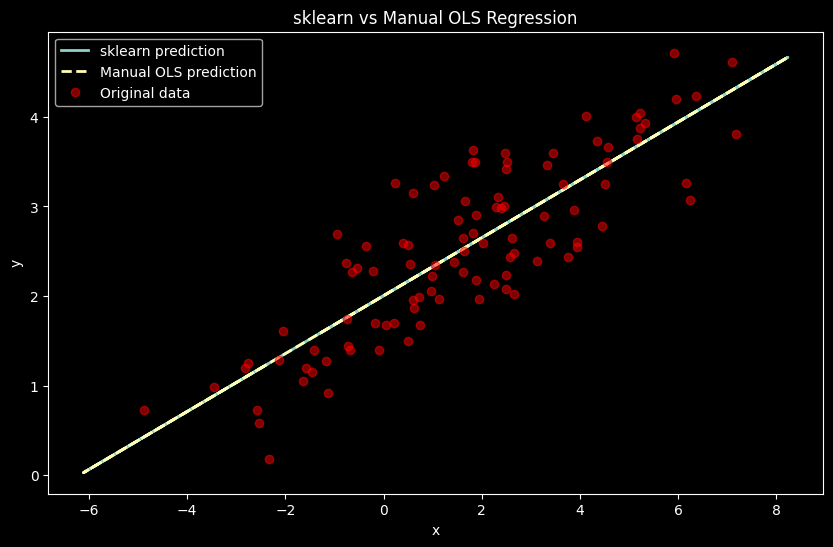

In [17]:
### Exercise A: Implement OLS manually

# Add a column of ones for the intercept term
X_with_intercept = np.column_stack([np.ones(len(x)), x])
y_col = y.reshape(-1, 1)

# Apply OLS formula: β* = (X^T X)^(-1) X^T y
beta = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y_col

print("Manual OLS coefficients:")
print(f"Intercept (β₀): {beta[0, 0]}")
print(f"Slope (β₁): {beta[1, 0]}")

print("\nsklearn coefficients:")
print(f"Intercept: {model.intercept_}")
print(f"Slope: {model.coef_[0]}")

# Verify they match
print(f"\nCoefficients match: {np.allclose(beta[0, 0], model.intercept_) and np.allclose(beta[1, 0], model.coef_[0])}")

# Plot comparison
new_x_test = 2.5 * np.random.randn(200).reshape(-1,1) + 1.5
predicted_sklearn = model.predict(new_x_test)

# Manual prediction
X_test_with_intercept = np.column_stack([np.ones(len(new_x_test)), new_x_test])
predicted_manual = X_test_with_intercept @ beta

plt.figure(figsize=(10, 6))
plt.plot(new_x_test, predicted_sklearn, label='sklearn prediction', linewidth=2)
plt.plot(new_x_test, predicted_manual, '--', label='Manual OLS prediction', linewidth=2)
plt.plot(x, y, 'ro', alpha=0.5, label='Original data')
plt.title('sklearn vs Manual OLS Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

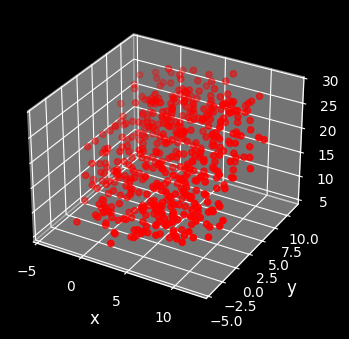

In [18]:
# Creating a pointcloud.
pc = o3d.io.read_point_cloud("TestData/spread_points.ply")
xyz = np.asarray(pc.points)

fig = plt.figure(figsize=(6,4))
ax = plt.axes(projection='3d')
ax.scatter3D(xyz[:,0], xyz[:,1], xyz[:,2], color = 'red')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('z', fontsize=12)
plt.show()


sklearn 3D plane coefficients:
Intercept (β₀): 10.813637419101848
Coefficient for x (β₁): 0.032449369359623975
Coefficient for y (β₂): 1.5269552195225364

Manual OLS 3D plane coefficients:
Intercept (β₀): 10.813637419101852
Coefficient for x (β₁): 0.03244936935962246
Coefficient for y (β₂): 1.526955219522537

Coefficients match: True


/var/folders/7m/h6flz5dn5tn1bd5d770t6n5r0000gp/T/ipykernel_69183/2370401954.py:21: RuntimeWarning: divide by zero encountered in matmul
  beta_3d = np.linalg.inv(X_3d.T @ X_3d) @ X_3d.T @ z
/var/folders/7m/h6flz5dn5tn1bd5d770t6n5r0000gp/T/ipykernel_69183/2370401954.py:21: RuntimeWarning: overflow encountered in matmul
  beta_3d = np.linalg.inv(X_3d.T @ X_3d) @ X_3d.T @ z
/var/folders/7m/h6flz5dn5tn1bd5d770t6n5r0000gp/T/ipykernel_69183/2370401954.py:21: RuntimeWarning: invalid value encountered in matmul
  beta_3d = np.linalg.inv(X_3d.T @ X_3d) @ X_3d.T @ z
/opt/homebrew/anaconda3/envs/pfas/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/opt/homebrew/anaconda3/envs/pfas/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))

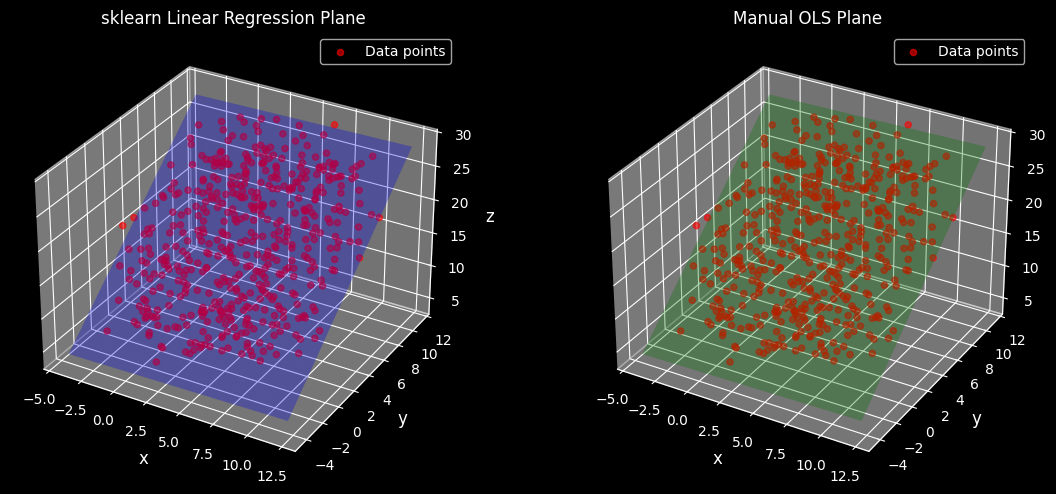


Plane equation: z = 10.8136 + 0.0324*x + 1.5270*y


In [19]:
### Exercise B: 3D Plane Fitting using Linear Regression

## We want to predict Z
xy = xyz[:,:2] # our inputs
z = xyz[:,2].reshape(-1,1) # our targets

# Method 1: Using sklearn
lm_3d = LinearRegression()
model_3d = lm_3d.fit(xy, z)

print("sklearn 3D plane coefficients:")
print(f"Intercept (β₀): {model_3d.intercept_[0]}")
print(f"Coefficient for x (β₁): {model_3d.coef_[0][0]}")
print(f"Coefficient for y (β₂): {model_3d.coef_[0][1]}")

# Method 2: Manual OLS for 3D
# Add intercept column: X = [1, x, y]
X_3d = np.column_stack([np.ones(len(xy)), xy])

# Apply OLS formula: β* = (X^T X)^(-1) X^T z
beta_3d = np.linalg.inv(X_3d.T @ X_3d) @ X_3d.T @ z

print("\nManual OLS 3D plane coefficients:")
print(f"Intercept (β₀): {beta_3d[0, 0]}")
print(f"Coefficient for x (β₁): {beta_3d[1, 0]}")
print(f"Coefficient for y (β₂): {beta_3d[2, 0]}")

print(f"\nCoefficients match: {np.allclose(beta_3d.flatten(), np.append(model_3d.intercept_, model_3d.coef_[0]))}")

# Visualize the plane
fig = plt.figure(figsize=(12, 5))

# Plot 1: sklearn plane
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter3D(xyz[:,0], xyz[:,1], xyz[:,2], color='red', alpha=0.6, label='Data points')

# Create mesh grid for plane
x_range = np.linspace(xyz[:,0].min(), xyz[:,0].max(), 20)
y_range = np.linspace(xyz[:,1].min(), xyz[:,1].max(), 20)
xx, yy = np.meshgrid(x_range, y_range)

# Predict z values for the mesh using sklearn
xy_mesh = np.c_[xx.ravel(), yy.ravel()]
zz_sklearn = model_3d.predict(xy_mesh).reshape(xx.shape)

ax1.plot_surface(xx, yy, zz_sklearn, alpha=0.3, color='blue')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_zlabel('z', fontsize=12)
ax1.set_title('sklearn Linear Regression Plane')
ax1.legend()

# Plot 2: Manual OLS plane
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter3D(xyz[:,0], xyz[:,1], xyz[:,2], color='red', alpha=0.6, label='Data points')

# Predict z values using manual OLS
X_mesh = np.column_stack([np.ones(len(xy_mesh)), xy_mesh])
zz_manual = (X_mesh @ beta_3d).reshape(xx.shape)

ax2.plot_surface(xx, yy, zz_manual, alpha=0.3, color='green')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_zlabel('z', fontsize=12)
ax2.set_title('Manual OLS Plane')
ax2.legend()

plt.tight_layout()
plt.show()

# Print plane equation
print(f"\nPlane equation: z = {beta_3d[0,0]:.4f} + {beta_3d[1,0]:.4f}*x + {beta_3d[2,0]:.4f}*y")